## Problem Set 3 for D400

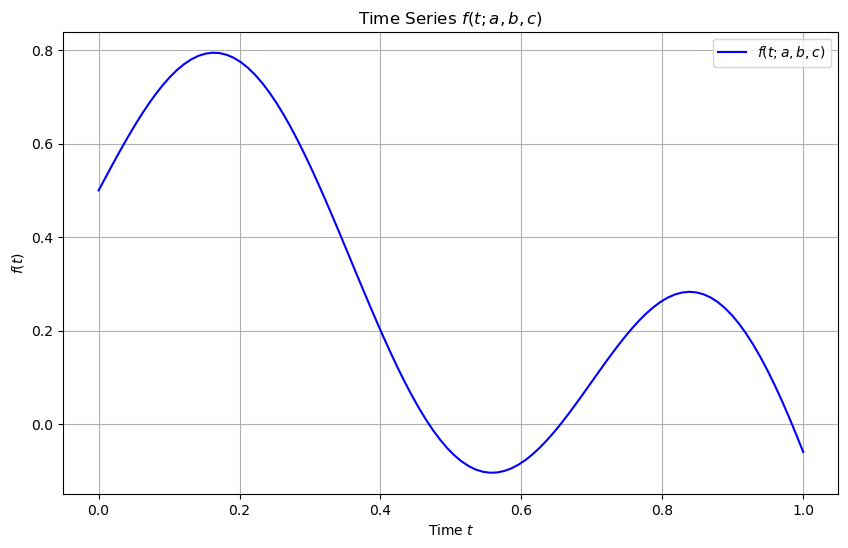

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

# Example usage
# Define parameters
a = 0.1
b = -0.13
c = 9


# Define time range
t = np.linspace(0, 1, 100)  # time from 0 to 1 with 100 points

# Calculate f(t) for these parameters
f_values = f(t, a, b, c)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()

Or with parameters...

In [ ]:
from ipywidgets import interactive
import ipywidgets as widgets


def plot_with_parameters(a, b, c):
    # Define time range
    t = np.linspace(0, 1, 100)

    # Calculate f(t) for these parameters
    f_values = f(t, a, b, c)

    # Plot the function
    plt.figure(figsize=(10, 6))
    plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
    plt.xlabel('Time $t$')
    plt.ylabel(r'$f(t)$')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.legend()
    plt.grid(True)
    plt.show()

# Create interactive widget
interactive_plot = interactive(
    plot_with_parameters,
    a=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.1),
    b=widgets.FloatSlider(min=-0.5, max=0.5, step=0.01, value=-0.13),
    c=widgets.FloatSlider(min=5, max=10, step=0.1, value=9)
)

display(interactive_plot)

interactive(children=(FloatSlider(value=0.1, description='a', max=1.0, step=0.01), FloatSlider(value=-0.13, de…

Question 1
Consider all parameter values (except t) are fixed and create an interpolator with respect to time t.

In [4]:
t = np.linspace(0, 1, 100)

from scipy.interpolate import interp1d

# Define time points and corresponding function values for a specific `a`
x = t  # Time points, assumed to be defined previously

y = f_values  # Function values at each time point `t` for a fixed `a`

# Create the interpolator function with respect to time `t`
F_interp_t = interp1d(x, y, kind='linear', fill_value="extrapolate")

Question 2
Evaluate the interpolator on a much finer grid than the original grid.

In [5]:
# Now you can use `F_interp_t` to interpolate the function at any time `t_new`
# Example:
t_new = np.linspace(0, 1, 1001) # An example time point within the range
f_value_at_t_new = F_interp_t(t_new)  # Interpolated value at t_new

Question 3
Show the results of question 2 in a plot, showing both the exact function and the predictions of the interpolator.

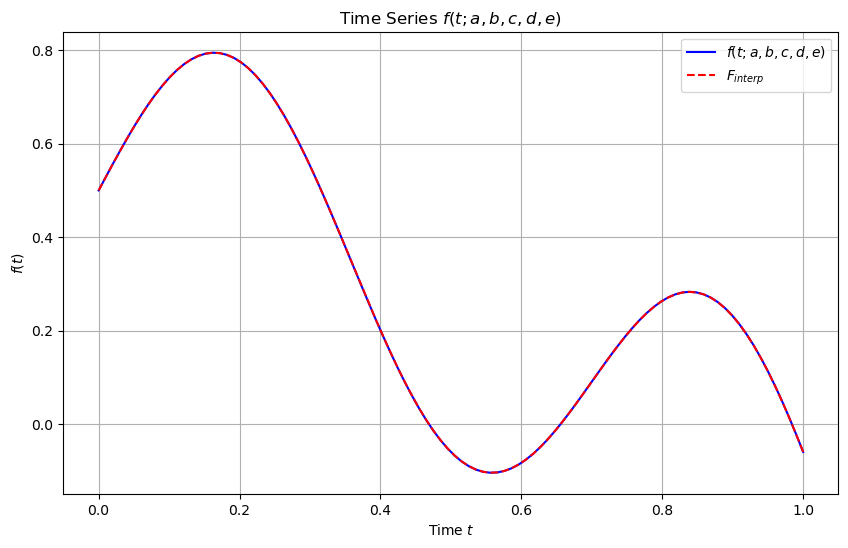

In [6]:
# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c, d, e)$', color='blue')
plt.plot(t_new, f_value_at_t_new, label=r'$F_{interp}$', color='red',ls='--')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c, d, e)$')
plt.legend()
plt.grid(True)
plt.show()

Question 4
Show the ratio of the interpolated values to true values accross the fine time grid.

What do you observe? Does it make sense?

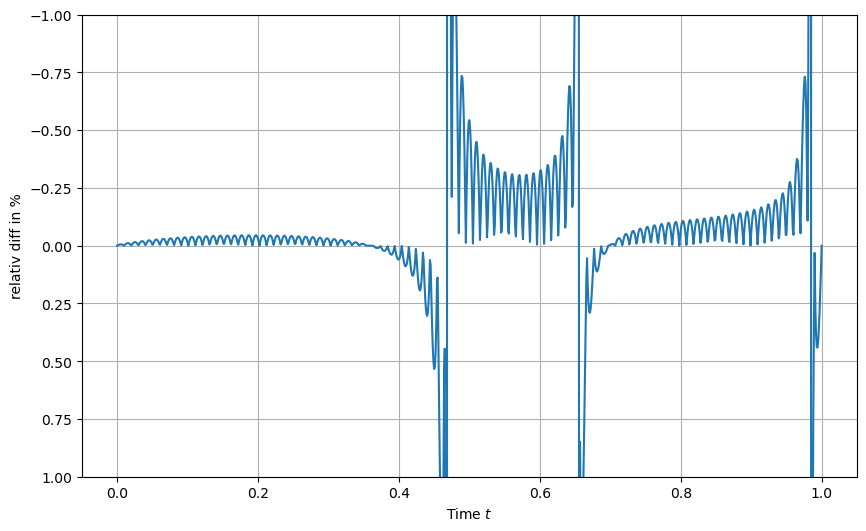

In [7]:
# Plot the function
plt.figure(figsize=(10, 6))

r = 100*(f_value_at_t_new-f(t_new, a, b, c))/f(t_new, a, b, c)
plt.plot(t_new, r)
plt.xlabel('Time $t$')
plt.ylabel(r'relativ diff in %')

plt.ylim(1,-1)
plt.grid(True)
plt.show()

The results are often very close together, and oscillate around zero, particularly around [0.0,0,4] and [0.5,0.6] for example. But, it diverges at particular points and in the neighbour of points where there are stationary points**

Question 5
Consider now all paramaters fixed except a
 (and 
t).

We assume the parameter a
 can take values between 0 and 1.

Generate 10 samples of f
 (i.e., 10 time series) corresponding to linearly spaced values of 
 spanning the interval.

Store them in a pandas DataFrame and plot them with the plot method of the DataFrame.